## CNN's and other cool neural networks stuff
```During this exercise you will train, examine and visualize convolutional neural networks. Images are a very unique example of high dimensional data. There are, indeed, many dimensions - even for low-resolution images (let's say, 32x32 pixels), while regarding each pixel as a feature, you can end up with hundreds of features. Such large vectors are, generally speaking, hard to visualize, but images make it all much easier, you can just draw the image. We will use this nice property to explore our networks. ```

~```Ittai Haran```

## Completed solution — guidelines and execution

Original instructions and code remain in their original order; only obsolete imports are updated. Each exercise has an adjacent solution and section-ending results.

- Seed 42; deterministic TensorFlow CPU operations and reproducible data partitions/batches.
- CIFAR-10: 45,000 training, 5,000 validation, 10,000 official test images. Faces: stratified 64%/16%/20%.
- Training uses training data only. Validation selects model types by macro one-vs-rest AUC; test metrics are final diagnostics.
- All model reports include loss, accuracy, balanced accuracy, macro AUC, confusion matrices, and class-level results.
- Dense training is limited to 40 epochs or 600 seconds. The prescribed CNN runs all 40 epochs; the frozen face classifier runs five.
- Model comparisons document architecture, optimizer, learning rate, initialization, batching, and duration. Different architectures need not yield identical predictions.
- Preserve original arrays, batch occlusion inference, and reuse frozen features. No silent model/data substitutions.
- Typed keyword-only numerical helpers, logged failures, and real-data tests support the notebook.
- Figures, model files, predictions, logs, and structured metrics are saved to a timestamped directory; the final results are exported to Excel.

The measured CPU estimate for this machine is 20–35 minutes with cached assets. Actual elapsed times are reported below. This is an educational evaluation on fixed small partitions, not evidence of deployment performance.

### Examining CNNs

In [1]:
from __future__ import annotations

from cnn_init import LOGGER, RANDOM_SEED, NOTEBOOK_DIRECTORY, REPOSITORY_DIRECTORY, CACHE_DIRECTORY, OUTPUT_DIRECTORY
import cnn_utils as solution_utils
import json
import math
from time import perf_counter
import tensorflow as tf
from tensorflow import keras
from IPython.display import Markdown, display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

tf.config.threading.set_intra_op_parallelism_threads(num_threads=16)
tf.config.threading.set_inter_op_parallelism_threads(num_threads=2)
keras.utils.set_random_seed(seed=RANDOM_SEED)
tf.config.experimental.enable_op_determinism()
LOGGER.info("TensorFlow %s; Keras %s; devices %s", tf.__version__, keras.__version__, tf.config.list_logical_devices())
ALL_RESULTS = []
TRAINING_RECORDS = []
CLASS_NAMES = list()
NOTEBOOK_STARTED = perf_counter()
asset_manifest = json.loads(s=(CACHE_DIRECTORY / "asset_manifest.json").read_text(encoding="utf-8"))
display(Markdown(data="**Runtime:** CPU/oneDNN, 16 compute threads. Original face assets and pretrained-weight provenance have been validated."))

2026-09-07 17:17:53,055 | INFO | Timestamped output directory: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part2\outputs\cnn_20260907_171753
2026-09-07 17:17:58,119 | INFO | TensorFlow 2.21.0; Keras 3.15.1; devices [LogicalDevice(name='/device:CPU:0', device_type='CPU')]


**Runtime:** CPU/oneDNN, 16 compute threads. Original face assets and pretrained-weight provenance have been validated.

In [2]:
import pandas as pd
import numpy as np
from keras.layers import Dense, Input, Conv2D, Flatten, MaxPool2D, Dropout, Softmax
from keras.models import Model

import matplotlib.pyplot as plt
%matplotlib inline

```As you recall, you used before the MNIST dataset. Now we will use a much harder dataset - CIFAR10, which contains low resolution images of 10 different objects - airplace, automobile, bird, cat, deer, dog, frog, horse, ship and truck. Start by loading the dataset.
Notice: the values given to pixels are in the range [0,255]. You might want to move them to the range [0,1] for later use in your neural networks.```

In [3]:
from keras.datasets import cifar10
(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()
num_to_words = {0:'airplane',1:'automobile',2:'bird',3:'cat', 4:'deer', 5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

In [4]:
# Solution: inspect raw data and create one shared validation split.
assert X_train.shape == (50_000, 32, 32, 3)
assert X_test.shape == (10_000, 32, 32, 3)
assert X_train.dtype == np.uint8 and X_test.dtype == np.uint8
assert X_train.min() >= 0 and X_train.max() <= 255
cifar_train_indices, cifar_validation_indices = train_test_split(
    np.arange(stop=len(X_train)), test_size=0.10, random_state=RANDOM_SEED,
    stratify=Y_train.reshape(-1),
)
assert np.intersect1d(ar1=cifar_train_indices, ar2=cifar_validation_indices).size == 0
cifar_training_images = X_train[cifar_train_indices].astype(dtype=np.float32) / 255.0
cifar_validation_images = X_train[cifar_validation_indices].astype(dtype=np.float32) / 255.0
cifar_test_images = X_test.astype(dtype=np.float32) / 255.0
cifar_training_targets = Y_train[cifar_train_indices].reshape(-1)
cifar_validation_targets = Y_train[cifar_validation_indices].reshape(-1)
cifar_test_targets = Y_test.reshape(-1)
cifar_names = [num_to_words[class_number] for class_number in range(10)]
cifar_partitions = {
    "train": (cifar_training_images, cifar_training_targets),
    "validation": (cifar_validation_images, cifar_validation_targets),
    "test": (cifar_test_images, cifar_test_targets),
}
display(pd.DataFrame(data=[
    {"partition": name, "images": len(targets), "dtype": str(images.dtype), "minimum": float(images.min()), "maximum": float(images.max()), "class_counts": np.unique(ar=targets, return_counts=True)[1].tolist()}
    for name, (images, targets) in cifar_partitions.items()
]))
np.savez_compressed(file=OUTPUT_DIRECTORY / "cifar_split_indices.npz", train=cifar_train_indices, validation=cifar_validation_indices)
# The explicit shuffle seed is independent of each model's dropout RNG.
def cifar_training_dataset() -> tf.data.Dataset:
    """Create an identical reproducible sequence of mini-batches for each model."""
    return tf.data.Dataset.from_tensor_slices(
        tensors=(cifar_training_images, keras.utils.to_categorical(x=cifar_training_targets, num_classes=10))
    ).shuffle(buffer_size=45_000, seed=RANDOM_SEED, reshuffle_each_iteration=True).batch(batch_size=128).prefetch(buffer_size=1)

cifar_validation_dataset = tf.data.Dataset.from_tensor_slices(
    tensors=(cifar_validation_images, keras.utils.to_categorical(x=cifar_validation_targets, num_classes=10))
).batch(batch_size=128).prefetch(buffer_size=1)

,partition,images,dtype,minimum,maximum,class_counts
0,train,45000,float32,0.0,1.0,"[4500, 4500, 4500, 4500, 4500, 4500, 4500, 450..."
1,validation,5000,float32,0.0,1.0,"[500, 500, 500, 500, 500, 500, 500, 500, 500, ..."
2,test,10000,float32,0.0,1.0,"[1000, 1000, 1000, 1000, 1000, 1000, 1000, 100..."


```Draw a random picture using plt.imshow function.```

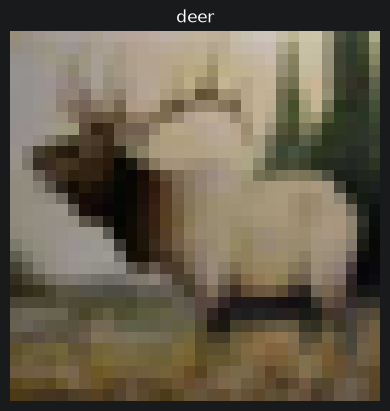

In [5]:
# Solution: random but reproducible sample, with the original RGB intensities preserved.
sample_number = int(np.random.default_rng(seed=RANDOM_SEED).integers(low=0, high=len(cifar_training_images)))
figure, axis = plt.subplots(figsize=(4, 4), layout="constrained")
axis.imshow(X=cifar_training_images[sample_number])
axis.set(title=cifar_names[cifar_training_targets[sample_number]])
axis.axis("off")
figure.savefig(fname=OUTPUT_DIRECTORY / "cifar_example.png", dpi=150)
plt.show()
plt.close(fig=figure)
# Restore the illustration referenced by the unchanged original instructions.
variation_example = solution_utils.get_blacked_variations(image=cifar_training_images[sample_number], square_size=4)
figure, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 2.3), layout="constrained")
for axis, position in zip(axes, (0, 264, 528, 792, 1023), strict=True):
    axis.imshow(X=variation_example[position])
    axis.set(title=f"Center {divmod(position, 32)}")
    axis.axis("off")
(NOTEBOOK_DIRECTORY / "resources").mkdir(exist_ok=True)
figure.savefig(fname=NOTEBOOK_DIRECTORY / "resources" / "image_for_notebook.png", dpi=150)
plt.close(fig=figure)

```Create a fully connected neural network that predicts the right class. after compiling your neural network (model.compile) you can use model.summary to print the architecture of your network. Use it, and make sure you have less than 2,000,000 parameters. Use any activations you'ld like.
Notice: Youl'd probably like to use the softmax activation on your last layer. Your network will have to get flattened vectors (or get matrices and flatten them on her own, using the Flatten layer) - what shape should your input have?
Use the adam optimizer. What should be the loss in this classification problem?```

In [6]:
# Diagnostic: tanh reached only 46.36% training accuracy in 40 epochs.
# ReLU is allowed by the exercise; all other settings remain fixed.
# Solution: (32,32,3) input is flattened to 3,072 features.
# Ten mutually exclusive classes require categorical cross-entropy and softmax.
keras.utils.set_random_seed(seed=RANDOM_SEED)
dense_input = keras.Input(shape=(32, 32, 3), name="cifar_rgb")
dense_hidden = keras.layers.Flatten()(inputs=dense_input)
for layer_number, hidden_units in enumerate((500, 200, 100, 50), start=1):
    dense_hidden = keras.layers.Dense(units=hidden_units, activation="relu", name=f"dense_{layer_number}")(inputs=dense_hidden)
dense_output = keras.layers.Dense(units=10, activation="softmax")(inputs=dense_hidden)
dense_model = keras.Model(inputs=dense_input, outputs=dense_output, name="cifar_dense")
dense_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
assert dense_model.count_params() == 1_662_360 < 2_000_000
dense_model.summary(print_fn=LOGGER.info)

2026-09-07 17:18:01,838 | INFO | Model: "cifar_dense"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cifar_rgb (InputLayer)          │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │     1,536,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200)            │       100,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────

```Train your network for 40 epochs (or 10 minutes, whichever comes faster) and get train accuracy of more than 0.6. What is the accuracy computed on the test? Would you say you are in overfit situation? explain your answer.```

2026-09-07 17:18:06,750 | INFO | Dense epoch 1 | {'accuracy': 0.2820444405078888, 'loss': 1.964235544204712, 'val_accuracy': 0.334199994802475, 'val_loss': 1.8399174213409424} | elapsed 4.6s
2026-09-07 17:18:09,675 | INFO | Dense epoch 2 | {'accuracy': 0.3705333471298218, 'loss': 1.7364004850387573, 'val_accuracy': 0.3903999924659729, 'val_loss': 1.7183880805969238} | elapsed 7.5s
2026-09-07 17:18:12,935 | INFO | Dense epoch 3 | {'accuracy': 0.4056222140789032, 'loss': 1.649456262588501, 'val_accuracy': 0.3959999978542328, 'val_loss': 1.6717991828918457} | elapsed 10.8s
2026-09-07 17:18:16,113 | INFO | Dense epoch 4 | {'accuracy': 0.43202221393585205, 'loss': 1.5839273929595947, 'val_accuracy': 0.4327999949455261, 'val_loss': 1.579397439956665} | elapsed 14.0s
2026-09-07 17:18:19,359 | INFO | Dense epoch 5 | {'accuracy': 0.44957777857780457, 'loss': 1.5354187488555908, 'val_accuracy': 0.4368000030517578, 'val_loss': 1.5734264850616455} | elapsed 17.2s
2026-09-07 17:18:22,533 | INFO | D

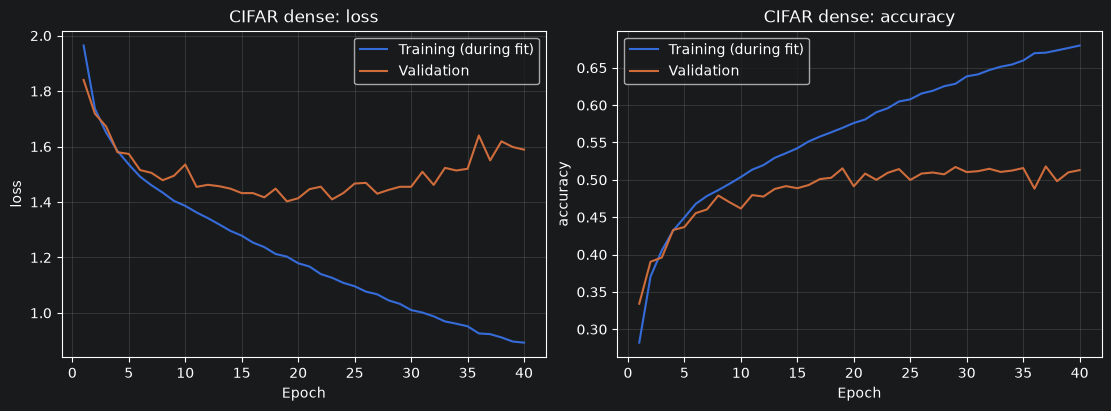

,model,partition,samples,loss,accuracy,balanced_accuracy,macro_auc
0,CIFAR dense,train,45000,0.824398,0.705889,0.705889,0.959496
1,CIFAR dense,validation,5000,1.587069,0.513000,0.513000,0.879567
2,CIFAR dense,test,10000,1.549163,0.517700,0.517700,0.882700


```text
train loss: 0.824398 | accuracy: 0.705889 | balanced accuracy: 0.705889 | AUC: 0.959496
validation loss: 1.587069 | accuracy: 0.513000 | balanced accuracy: 0.513000 | AUC: 0.879567
test loss: 1.549163 | accuracy: 0.517700 | balanced accuracy: 0.517700 | AUC: 0.882700
```

,precision,recall,f1-score,support
airplane,0.598837,0.6180,0.608268,1000.0000
automobile,0.622967,0.6130,0.617944,1000.0000
bird,0.434903,0.3140,0.364692,1000.0000
cat,0.358354,0.2960,0.324206,1000.0000
deer,0.416385,0.4930,0.451465,1000.0000
dog,0.405505,0.4420,0.422967,1000.0000
frog,0.518229,0.5970,0.554833,1000.0000
horse,0.622577,0.5460,0.581779,1000.0000
ship,0.603943,0.6740,0.637051,1000.0000
truck,0.574238,0.5840,0.579078,1000.0000


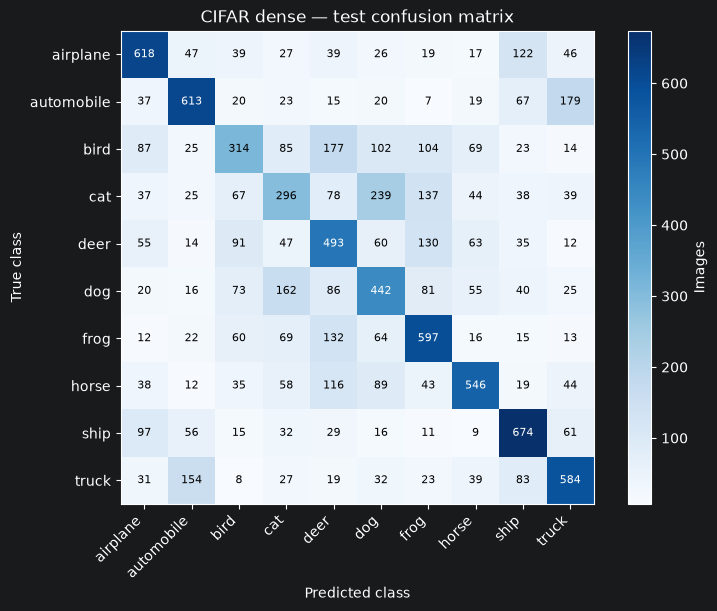

**Answer — dense model.** Final inference-mode train accuracy is 70.59%; test accuracy is 51.77%. The train-minus-validation accuracy gap is 19.29%. Training loss is 0.8244 versus validation loss 1.5871. A higher training accuracy together with lower training loss is evidence of overfitting; compare the learning curves to distinguish this from continuing underfitting. The required train accuracy >60% is **met**. Actual duration: 129.4 seconds, 40 epochs.

In [7]:
dense_started = perf_counter()
dense_history = dense_model.fit(
    x=cifar_training_dataset(), validation_data=cifar_validation_dataset,
    epochs=40, callbacks=[solution_utils.TrainingLogger(label="Dense", maximum_seconds=600.0)],
    verbose=0, shuffle=False,
)
dense_elapsed = perf_counter() - dense_started
dense_results = []
for partition, (images, targets) in cifar_partitions.items():
    probabilities = dense_model.predict(x=images, batch_size=128, verbose=0)
    dense_results.append(solution_utils.evaluate_probabilities(model_name="CIFAR dense", partition=partition, targets=targets, probabilities=probabilities, class_names=cifar_names))
    np.savez_compressed(file=OUTPUT_DIRECTORY / f"dense_{partition}_predictions.npz", targets=targets, probabilities=probabilities)
ALL_RESULTS.extend(dense_results)
TRAINING_RECORDS.append({"model": "CIFAR dense", "epochs": len(dense_history.epoch), "seconds": dense_elapsed, "parameters": dense_model.count_params(), "optimizer": "Adam", "learning_rate": 0.001, "batch_size": 128})
solution_utils.plot_history(history=dense_history, title="CIFAR dense", output_directory=OUTPUT_DIRECTORY, file_name="dense_learning_curves.png")
solution_utils.report_results(results=dense_results, class_names=cifar_names, output_directory=OUTPUT_DIRECTORY, file_name="dense_confusion_matrix.png")
dense_model.save(filepath=OUTPUT_DIRECTORY / "cifar_dense.keras")
dense_gap = dense_results[0]["accuracy"] - dense_results[1]["accuracy"]
display(Markdown(data=f"""**Answer — dense model.** Final inference-mode train accuracy is {dense_results[0]['accuracy']:.2%}; test accuracy is {dense_results[2]['accuracy']:.2%}. The train-minus-validation accuracy gap is {dense_gap:.2%}. Training loss is {dense_results[0]['loss']:.4f} versus validation loss {dense_results[1]['loss']:.4f}. A higher training accuracy together with lower training loss is evidence of overfitting; compare the learning curves to distinguish this from continuing underfitting. The required train accuracy >60% is **{'met' if dense_results[0]['accuracy'] > 0.60 else 'not met'}**. Actual duration: {dense_elapsed:.1f} seconds, {len(dense_history.epoch)} epochs."""))
if dense_results[0]["accuracy"] <= 0.60:
    LOGGER.error("Dense assignment target not met; stopping for diagnosis.")
    raise AssertionError("Dense model must exceed 60% training accuracy")

```We will now attack the same problem using a simple CNN. Build a CNN model as follows:```
- ```Input layer```
- ```Convolutional layer of 32 filters of size (3,3) with relu activation```
- ```Convolutional layer of 32 filters of size (3,3) with relu activation```
- ```Max pooling layer```
- ```Dropout layer of p=0.25```
- ```Convolutional layer of 64 filters of size (3,3) with relu activation```
- ```Convolutional layer of 64 filters of size (3,3) with relu activation```
- ```Max pooling layer```
- ```Dropout layer of p=0.25```
- ```Flattning layer (Flatten in keras)```
- ```Fully connected layer of 200 hidden units```
- ```Dropout layer of p=0.5```
- ```Output layer```

```Use the same loss as with the fully connected model and the same optimizer. How many weights are there in your network? Train it for 40 epochs. What train loss did you get? What test loss did you get? How is it similar to the fully connected case?```

2026-09-07 17:20:16,495 | INFO | Model: "cifar_cnn"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├───────────────────────

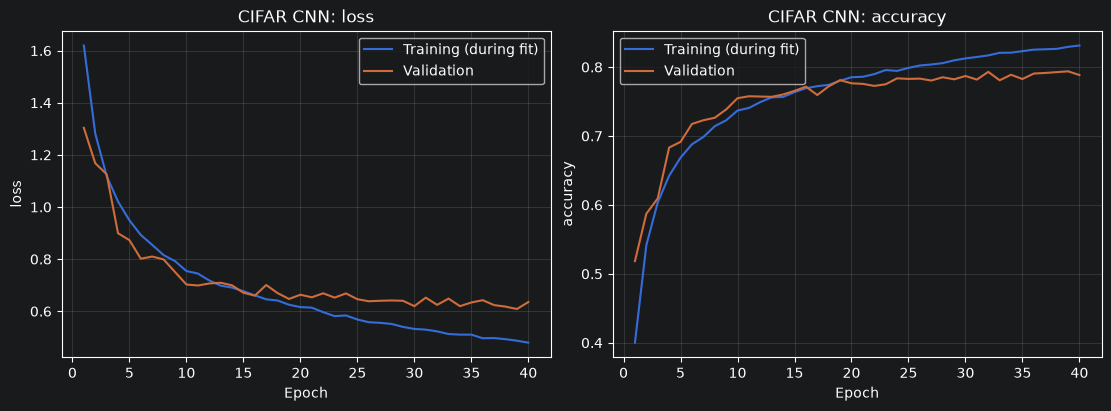

,model,partition,samples,loss,accuracy,balanced_accuracy,macro_auc
0,CIFAR CNN,train,45000,0.287662,0.901133,0.901133,0.994556
1,CIFAR CNN,validation,5000,0.635283,0.788400,0.788400,0.977033
2,CIFAR CNN,test,10000,0.643458,0.786200,0.786200,0.976791


```text
train loss: 0.287662 | accuracy: 0.901133 | balanced accuracy: 0.901133 | AUC: 0.994556
validation loss: 0.635283 | accuracy: 0.788400 | balanced accuracy: 0.788400 | AUC: 0.977033
test loss: 0.643458 | accuracy: 0.786200 | balanced accuracy: 0.786200 | AUC: 0.976791
```

,precision,recall,f1-score,support
airplane,0.813765,0.8040,0.808853,1000.0000
automobile,0.940347,0.8670,0.902185,1000.0000
bird,0.677543,0.7060,0.691479,1000.0000
cat,0.621272,0.6250,0.623131,1000.0000
deer,0.736007,0.7890,0.761583,1000.0000
dog,0.724731,0.6740,0.698446,1000.0000
frog,0.746878,0.8970,0.815084,1000.0000
horse,0.909548,0.7240,0.806236,1000.0000
ship,0.887765,0.8780,0.882856,1000.0000
truck,0.851992,0.8980,0.874391,1000.0000


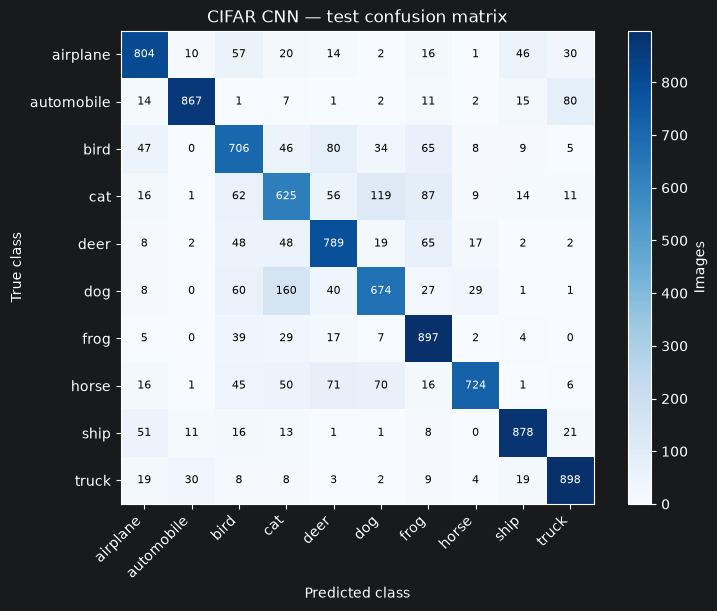

**Answer — CNN comparison.** The CNN has 387,778 parameters. Its inference-mode train loss is 0.2877, and test loss is 0.6435. The dense model's corresponding losses are 0.8244 and 1.5492. Validation macro AUC selects **CIFAR CNN** (0.97703). Both models share the data, optimizer, learning rate, batches, and epoch ceiling; they differ in architecture, activations, dropout, and parameter count. Matching these outcomes is not expected. Training curves include active dropout and changing weights; the final train/validation/test reports all use inference mode. Test results do not influence selection.

,model,epochs,seconds,parameters,optimizer,learning_rate,batch_size
0,CIFAR dense,40,129.392962,1662360,Adam,0.001,128
1,CIFAR CNN,40,553.674393,387778,Adam,0.001,128


In [8]:
# Solution: exact prescribed CNN, including valid padding and all dropout layers.
keras.utils.set_random_seed(seed=RANDOM_SEED)
cnn_input = keras.Input(shape=(32, 32, 3))
cnn_hidden = cnn_input
for block_number, filters in enumerate((32, 64), start=1):
    for convolution_number in (1, 2):
        cnn_hidden = keras.layers.Conv2D(filters=filters, kernel_size=(3, 3), padding="valid", activation="relu", name=f"block{block_number}_conv{convolution_number}")(inputs=cnn_hidden)
    cnn_hidden = keras.layers.MaxPooling2D(pool_size=(2, 2))(inputs=cnn_hidden)
    cnn_hidden = keras.layers.Dropout(rate=0.25, seed=RANDOM_SEED + block_number)(inputs=cnn_hidden)
cnn_hidden = keras.layers.Flatten()(inputs=cnn_hidden)
cnn_hidden = keras.layers.Dense(units=200, activation="tanh")(inputs=cnn_hidden)
cnn_hidden = keras.layers.Dropout(rate=0.5, seed=RANDOM_SEED + 3)(inputs=cnn_hidden)
cnn_output = keras.layers.Dense(units=10, activation="softmax")(inputs=cnn_hidden)
cnn_model = keras.Model(inputs=cnn_input, outputs=cnn_output, name="cifar_cnn")
cnn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
assert cnn_model.count_params() == 387_778
cnn_model.summary(print_fn=LOGGER.info)
cnn_started = perf_counter()
cnn_history = cnn_model.fit(x=cifar_training_dataset(), validation_data=cifar_validation_dataset, epochs=40, shuffle=False, callbacks=[solution_utils.TrainingLogger(label="CNN")], verbose=0)
cnn_elapsed = perf_counter() - cnn_started
assert len(cnn_history.epoch) == 40
cnn_results = []
cnn_probabilities = {}
for partition, (images, targets) in cifar_partitions.items():
    probabilities = cnn_model.predict(x=images, batch_size=128, verbose=0)
    cnn_probabilities[partition] = probabilities
    cnn_results.append(solution_utils.evaluate_probabilities(model_name="CIFAR CNN", partition=partition, targets=targets, probabilities=probabilities, class_names=cifar_names))
    np.savez_compressed(file=OUTPUT_DIRECTORY / f"cnn_{partition}_predictions.npz", targets=targets, probabilities=probabilities)
ALL_RESULTS.extend(cnn_results)
TRAINING_RECORDS.append({"model": "CIFAR CNN", "epochs": 40, "seconds": cnn_elapsed, "parameters": cnn_model.count_params(), "optimizer": "Adam", "learning_rate": 0.001, "batch_size": 128})
solution_utils.plot_history(history=cnn_history, title="CIFAR CNN", output_directory=OUTPUT_DIRECTORY, file_name="cnn_learning_curves.png")
solution_utils.report_results(results=cnn_results, class_names=cifar_names, output_directory=OUTPUT_DIRECTORY, file_name="cnn_confusion_matrix.png")
cnn_model.save(filepath=OUTPUT_DIRECTORY / "cifar_cnn.keras")
cifar_winner = max([dense_results[1], cnn_results[1]], key=lambda result: result["macro_auc"])
display(Markdown(data=f"""**Answer — CNN comparison.** The CNN has {cnn_model.count_params():,} parameters. Its inference-mode train loss is {cnn_results[0]['loss']:.4f}, and test loss is {cnn_results[2]['loss']:.4f}. The dense model's corresponding losses are {dense_results[0]['loss']:.4f} and {dense_results[2]['loss']:.4f}. Validation macro AUC selects **{cifar_winner['model']}** ({cifar_winner['macro_auc']:.5f}). Both models share the data, optimizer, learning rate, batches, and epoch ceiling; they differ in architecture, activations, dropout, and parameter count. Matching these outcomes is not expected. Training curves include active dropout and changing weights; the final train/validation/test reports all use inference mode. Test results do not influence selection."""))
display(pd.DataFrame(data=TRAINING_RECORDS))

```We will now experience with visualization and interpretation of the network. Given a single image, we would like to know what parts of the image contribute most to the prediction of the network. In order to do, each time we will black out part of the image, to get all the possible images with blacked out part:```

![title](resources/image_for_notebook.png)

```In total you will have, for a 32x32 image, 1,024 blacked images. Write a function that, given an image (32x32x3 matrix) and a parameter``` $a$ ```, creates a new tensor (of shape 1024x32x32x3) so that tensor[num] is the original image with a blacked out square of edge size``` $a$ ```, concentrated around the (num//32,num%32)-pixel. We will call the output tensor the "variation tensor".```

In [9]:
# Solution: implementation is in the tested, adjacent cnn_utils module.
from cnn_utils import get_blacked_variations, mark_focus
variation_tensor = get_blacked_variations(image=cifar_test_images[0], square_size=4)
assert variation_tensor.shape == (1024, 32, 32, 3)
assert variation_tensor.dtype == np.float32
display(Markdown(data="""**Square convention.** For edge length a, the square starts at center − floor(a/2) and covers a pixels per axis before clipping to the image boundary. Thus a=4 uses offsets −2, −1, 0, +1. At the borders the visible square is smaller. Variations use about 12 MiB per image in float32; the source data are unchanged."""))

**Square convention.** For edge length a, the square starts at center − floor(a/2) and covers a pixels per axis before clipping to the image boundary. Thus a=4 uses offsets −2, −1, 0, +1. At the borders the visible square is smaller. Variations use about 12 MiB per image in float32; the source data are unchanged.

```Use``` $a=4$ ```and choose a random image from the test segment that got labeled correctly using your model. Create, using the function you recently wrote, the variation tensor. Create the model's predictions for every blacked image in the tensor (using model.predict(tensor)).
You will get a matrix of shape 1024x10. Take only the column that matches the image's label, so you get a 1024-dimensions vector. Reshape it to be a 32x32 image. Now every pixel tells the probability of the model to label the image correctly, while there is a blacked out square concentrated around that pixel. Show the original image and the image you got. Normalize the scale of the image you got to the range [0,1] using plt.imshow(..., vmin=0, vmax=1).
Take your time to examine the procedure you just created on different images.```

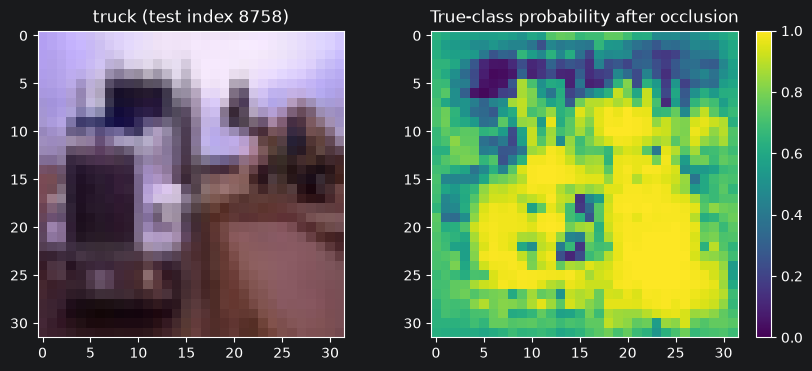

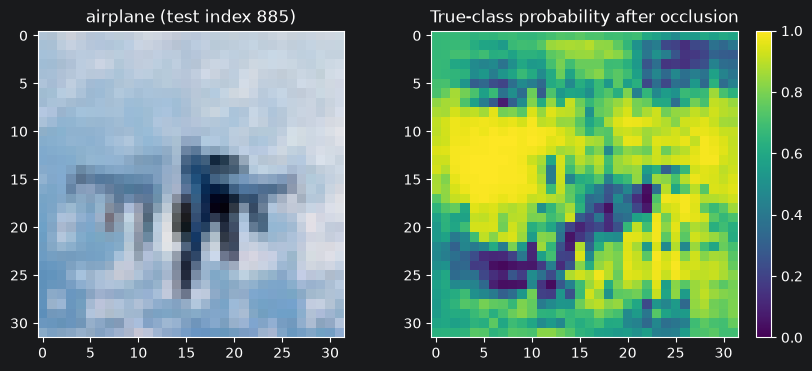

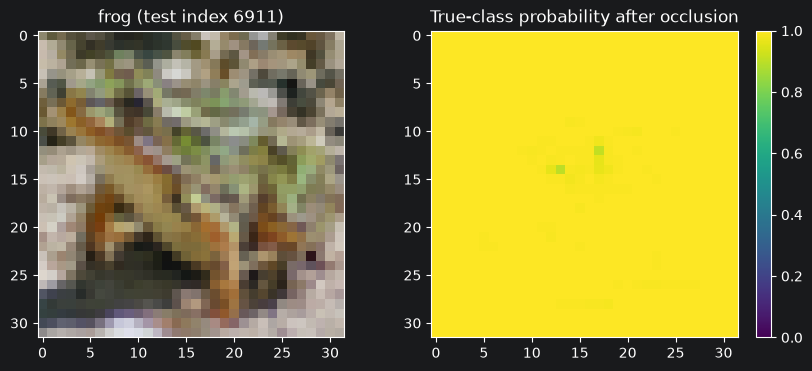

In [10]:
occlusion_generator = np.random.default_rng(seed=RANDOM_SEED)
correct_cifar = np.argmax(a=cnn_probabilities["test"], axis=1) == cifar_test_targets
occlusion_examples = []
for class_number in occlusion_generator.choice(a=10, size=3, replace=False):
    candidates = np.flatnonzero(a=correct_cifar & (cifar_test_targets == class_number))
    assert candidates.size > 0
    test_index = int(occlusion_generator.choice(a=candidates))
    source_image = cifar_test_images[test_index]
    variations = get_blacked_variations(image=source_image, square_size=4)
    probabilities = cnn_model.predict(x=variations, batch_size=128, verbose=0)
    assert probabilities.shape == (1024, 10)
    heatmap = probabilities[:, class_number].reshape(32, 32)
    occlusion_examples.append({"index": test_index, "class": int(class_number), "heatmap": heatmap})
    figure, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 3.6), layout="constrained")
    axes[0].imshow(X=source_image)
    axes[0].set(title=f"{cifar_names[class_number]} (test index {test_index})")
    color_image = axes[1].imshow(X=heatmap, vmin=0, vmax=1, cmap="viridis")
    axes[1].set(title="True-class probability after occlusion")
    figure.colorbar(mappable=color_image, ax=axes[1])
    figure.savefig(fname=OUTPUT_DIRECTORY / f"occlusion_{test_index}.png", dpi=150)
    plt.show()
    plt.close(fig=figure)

```You can get a concept of "network focus" using the visualization you created.
Given the heatmap you created, find the 80 pixels with smallest values. That means, the pixels that, when removing a square around them, we get the maximum damage to the network prediction. Mark these pixels in the original image (actually, in a copy of the original image - you don't want to destroy your data) by adding 0.5 to the red component of the rgb.
Show the original image, the heatmap image and the marked image.```

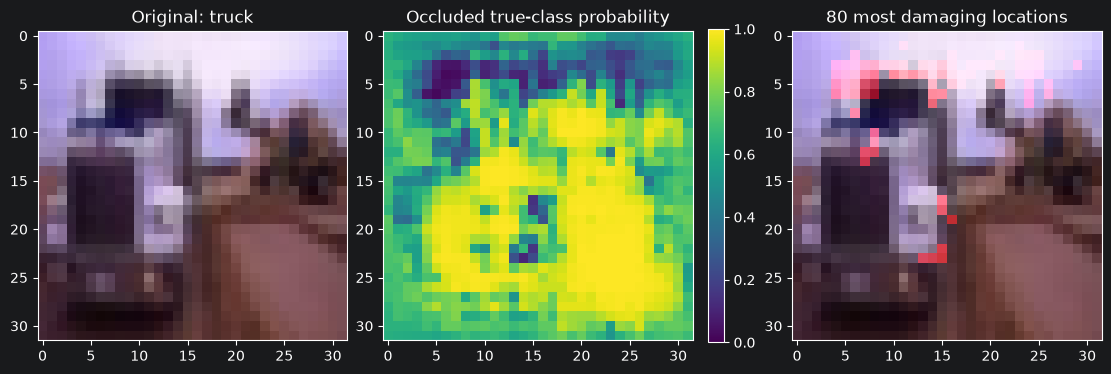

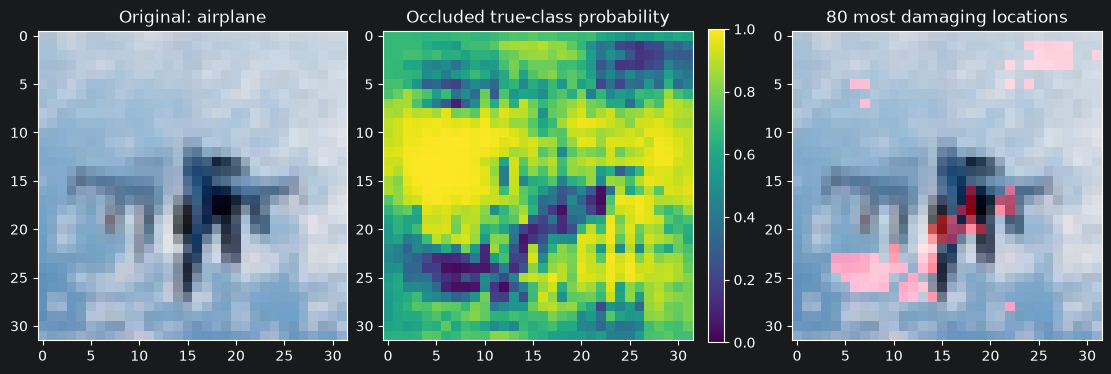

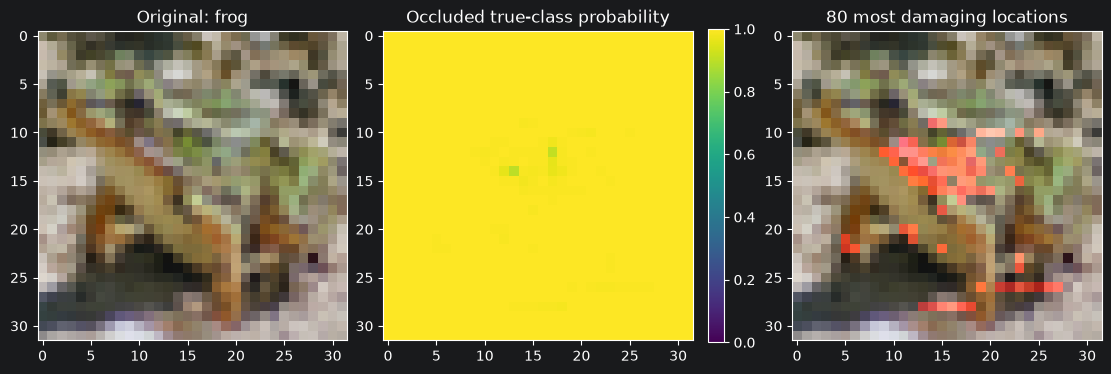

**Interpretation.** Darker heatmap locations correspond to lower true-class probability when that patch is hidden. The red markings identify exactly 80 such patch centers, with deterministic tie handling. Neighboring patches overlap, and a black patch is an artificial image alteration, so this is a sensitivity visualization rather than proof of causal importance.

In [11]:
for example in occlusion_examples:
    source_image = cifar_test_images[example["index"]]
    marked_image, selected_mask = mark_focus(image=source_image, heatmap=example["heatmap"], number_of_pixels=80)
    assert int(selected_mask.sum()) == 80
    np.testing.assert_array_equal(actual=marked_image[..., 1:], desired=source_image[..., 1:])
    figure, axes = plt.subplots(nrows=1, ncols=3, figsize=(11, 3.6), layout="constrained")
    axes[0].imshow(X=source_image)
    axes[0].set(title=f"Original: {cifar_names[example['class']]}")
    color_image = axes[1].imshow(X=example["heatmap"], vmin=0, vmax=1, cmap="viridis")
    axes[1].set(title="Occluded true-class probability")
    figure.colorbar(mappable=color_image, ax=axes[1])
    axes[2].imshow(X=marked_image)
    axes[2].set(title="80 most damaging locations")
    figure.savefig(fname=OUTPUT_DIRECTORY / f"focus_{example['index']}.png", dpi=150)
    plt.show()
    plt.close(fig=figure)
display(Markdown(data="""**Interpretation.** Darker heatmap locations correspond to lower true-class probability when that patch is hidden. The red markings identify exactly 80 such patch centers, with deterministic tie handling. Neighboring patches overlap, and a black patch is an artificial image alteration, so this is a sensitivity visualization rather than proof of causal importance."""))

### Transfer learning

```We've talked in class about transfer learning. Here you will experience with a simple task of transfer learning. We will take a VGGFace model, trained to predict faces among 2,622 classes, and use it to discriminate between the faces of following celebrities: Alicia Vikander, Amy Adams and Andy Serkis. We will do it by cutting out the last layers and replacing them with layers of our own.```

### Solution — compatibility and data discipline

The original VGGFace weights and 2,622 identities are retained. A small local loader reconstructs that architecture using installed Keras layers; slash-containing activation names become `fc6_relu` and `fc7_relu`. No ImageNet model is substituted.

The only edits to original code are the imports below. The public TensorFlow augmentation import is available in this environment. Source: [original VGGFace implementation](https://github.com/rcmalli/keras-vggface).

In [12]:
from cnn_utils import build_vggface as VGGFace
import cnn_utils as utils # original VGGFace weights through installed Keras primitives
from sklearn.model_selection import train_test_split

#This next import will help you with augmentation - generating augmented photos from your originals.
#Read about this general teqnique, and also about ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Flatten, Dense
from keras.models import Model

```Start by loading the data in images.pkl and in images_labels.pkl. Show an image of Alicia, Amy and Andy, and make sure you can tell the difference ;)```

(can be found in: https://drive.google.com/open?id=1go4U-nI4H5kBz6hstI4_PYtzS35jHEDM)

,celebrity,images
0,Alicia Vikander,112
1,Amy Adams,119
2,Andy Serkis,126


2026-09-07 17:29:43,860 | INFO | Face data: (357, 224, 224, 3), uint8; values 0..255


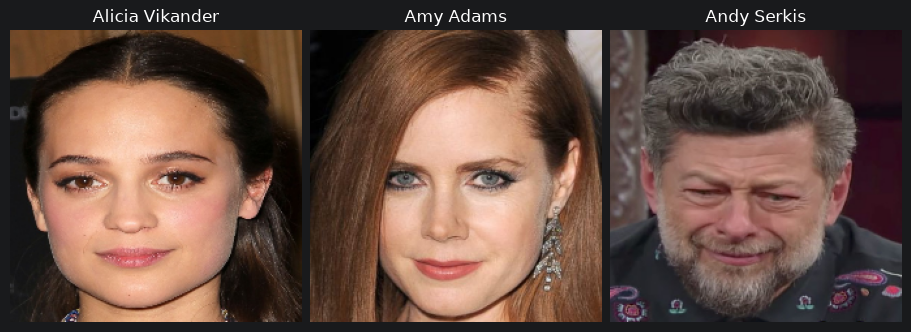

In [13]:
face_images, face_labels, face_example = utils.load_face_data()
face_encoder = LabelEncoder()
face_targets = face_encoder.fit_transform(y=face_labels)
face_names = face_encoder.classes_.tolist()
assert face_names == ["Alicia Vikander", "Amy Adams", "Andy Serkis"]
assert face_images.shape == (357, 224, 224, 3)
display(pd.DataFrame(data={"celebrity": face_names, "images": np.unique(ar=face_targets, return_counts=True)[1]}))
LOGGER.info("Face data: %s, %s; values %d..%d", face_images.shape, face_images.dtype, face_images.min(), face_images.max())
figure, axes = plt.subplots(nrows=1, ncols=3, figsize=(9, 3.4), layout="constrained")
for class_number, axis in enumerate(axes):
    image_index = np.flatnonzero(a=face_targets == class_number)[0]
    axis.imshow(X=face_images[image_index])
    axis.set(title=face_names[class_number])
    axis.axis("off")
figure.savefig(fname=OUTPUT_DIRECTORY / "face_classes.png", dpi=150)
plt.show()
plt.close(fig=figure)

```In transfer learning we take a trained model, cut off its end and replace it with some layers of our own. Hence we will have to preprocess our data the same way it was preprocessed when training VGGFace. Use the following line to do so:```
```python
X_processed = utils.preprocess_input(X.copy().astype(float), version=1)
```
```Transform the values of Y to be [1 0] or [0 1]. Split your data to 80% train data and 20% test data.```

**Solution correction.** There are three mutually exclusive celebrities, so the labels are three-element one-hot vectors and the loss is categorical cross-entropy. The original two-element example above is a typo. We keep its 20% test allocation and reserve 20% of the remaining development data for validation. Preprocessing uses raw RGB intensities in [0,255], converts RGB to BGR, and subtracts VGGFace's channel means; it does not divide by 255.

In [14]:
face_development_indices, face_test_indices = train_test_split(
    np.arange(stop=len(face_targets)), test_size=0.20, random_state=RANDOM_SEED, stratify=face_targets,
)
face_training_indices, face_validation_indices = train_test_split(
    face_development_indices, test_size=0.20, random_state=RANDOM_SEED + 1, stratify=face_targets[face_development_indices],
)
face_indices = {"train": face_training_indices, "validation": face_validation_indices, "test": face_test_indices}
assert len(set(face_training_indices) | set(face_validation_indices) | set(face_test_indices)) == len(face_targets)
assert sum(len(indices) for indices in face_indices.values()) == len(face_targets)
face_processed = utils.preprocess_input(x=face_images, version=1)
face_one_hot = keras.utils.to_categorical(x=face_targets, num_classes=3)
np.savez_compressed(file=OUTPUT_DIRECTORY / "face_split_indices.npz", **face_indices)
display(pd.DataFrame(data=[{"partition": partition, "images": len(indices), "class_counts": np.unique(ar=face_targets[indices], return_counts=True)[1].tolist()} for partition, indices in face_indices.items()]))

,partition,images,class_counts
0,train,228,"[71, 76, 81]"
1,validation,57,"[18, 19, 20]"
2,test,72,"[23, 24, 25]"


```Let's look at the VGGFace model we are about to use. Load it:```

In [15]:
vgg_model = VGGFace()

2026-09-07 17:29:45,847 | INFO | Loaded all 145002878 VGGFace parameters from C:\Users\asherk\PycharmProjects\DS_Training\.cache\cnn\vggface_vgg16.h5


```The model is fitted to predict the name of the celebrity in the pictures it gets. Read the example picture given to you in face_example.pkl. Show it. Transform it into a tensor of shape (1, 224, 224, 3) and use utils.preprocess_input as seen before to get it ready to enter to your network. Use```
```python
utils.decode_predictions(model.predict(x))
```
```To get 5 most probable classes. Who is the man in the picture?```

2026-09-07 17:29:45,958 | INFO | Model: "vggface_vgg16"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ face_rgb (InputLayer)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 112, 112, 128)  │        73,856 │
├───────────────────

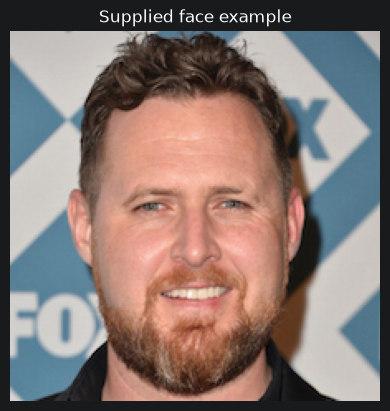

,predicted_identity,probability
0,A.J._Buckley,0.979009
1,David_Denman,0.001446
2,Carmine_Giovinazzo,0.000868
3,Robert_Buckley,0.000725
4,Eddie_Cahill,0.000418


**Answer.** The pretrained model's highest-ranked identity is **A.J._Buckley** with probability 0.9790. The table gives its five most probable identities; these are model predictions.

In [16]:
# Solution: the original VGGFace() cell above loaded all published face weights.
vgg_model.summary(print_fn=LOGGER.info)
assert face_example.shape == (224, 224, 3)
example_probabilities = vgg_model.predict(x=utils.preprocess_input(x=face_example[None, ...]), batch_size=1, verbose=0)
top_faces = utils.decode_predictions(preds=example_probabilities, top=5)[0]
figure, axis = plt.subplots(figsize=(4, 4), layout="constrained")
axis.imshow(X=face_example.astype(dtype=np.uint8))
axis.set(title="Supplied face example")
axis.axis("off")
figure.savefig(fname=OUTPUT_DIRECTORY / "face_example.png", dpi=150)
plt.show()
plt.close(fig=figure)
display(pd.DataFrame(data=top_faces, columns=["predicted_identity", "probability"]))
display(Markdown(data=f"**Answer.** The pretrained model's highest-ranked identity is **{top_faces[0][0]}** with probability {top_faces[0][1]:.4f}. The table gives its five most probable identities; these are model predictions."))

```Let's return to our dataset. As you could impress, it's a pretty small one. Hence we can try to make it bigger using augmentations of the data. We will do it here using a mechanism supplied by keras. Create an instance of keras.preprocessing.image.ImageDataGenerator, which will define how you will create augmentations of each original image you've created. Choose all the parameters on your own (consider, for example, rotation_range, zoom_range, width_shift_range, horizontal_flip and so on).```

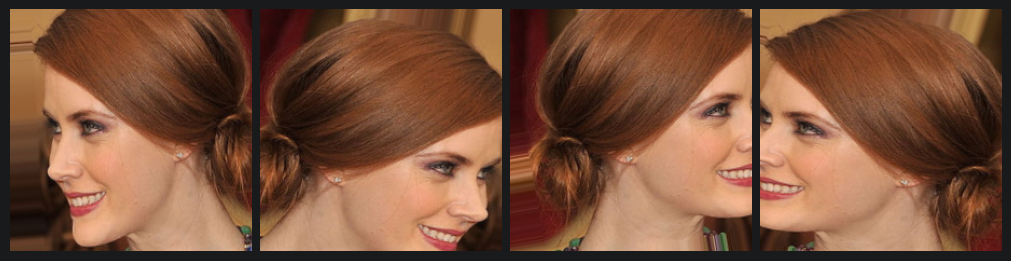

In [17]:
# Solution: apply moderate augmentation to RGB values before channel preprocessing.
# The adapter is positional because ImageDataGenerator invokes this callback positionally.
def augment_preprocess(image: np.ndarray) -> np.ndarray:
    """Apply VGGFace preprocessing using ImageDataGenerator's callback interface."""
    return utils.preprocess_input(x=image, version=1)

face_augmentor = ImageDataGenerator(
    rotation_range=15, width_shift_range=0.10, height_shift_range=0.10,
    zoom_range=0.20, horizontal_flip=True, fill_mode="nearest",
    preprocessing_function=augment_preprocess,
)
face_training_generator = face_augmentor.flow(
    x=face_images[face_training_indices].astype(dtype=np.float32),
    y=face_one_hot[face_training_indices], batch_size=20, shuffle=True, seed=RANDOM_SEED,
)
# Visualize the transforms in RGB with a separate iterator so training order is unaffected.
preview_augmentor = ImageDataGenerator(rotation_range=15, width_shift_range=0.10, height_shift_range=0.10, zoom_range=0.20, horizontal_flip=True, fill_mode="nearest")
preview_generator = preview_augmentor.flow(x=face_images[face_training_indices[:1]].astype(dtype=np.float32), batch_size=1, seed=RANDOM_SEED, shuffle=False)
figure, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3), layout="constrained")
for axis in axes:
    axis.imshow(X=np.clip(a=next(preview_generator)[0] / 255.0, a_min=0.0, a_max=1.0))
    axis.axis("off")
figure.savefig(fname=OUTPUT_DIRECTORY / "face_augmentations.png", dpi=150)
plt.show()
plt.close(fig=figure)

```Follow the following instructions:```
- ```Examine the architecture of the VGGFace model using .summary(). Understand what it means to replace the last 2 dense layers (including the final softmax layer). How many weights are there in the model?```
- ```Use .get_layer() to retrieve the last layer which you want to keep in your new network```
- ```Create 2 new Dense layers which continue the previous pretrained layers (the last layer should have a softmax activation, for the first one try tanh)```
- ```Create a new model with the input of the original model as input (vgg_model.input), and which outputs the new dense-softmax layer```
- ```Freeze all of the layers except the last 2 using .layers on the new model, and .trainable = False. This will stop you from training those layers```
- ```Compile the model with sgd optimizer and with metric=['accuracy'] (what does it do?)```

In [18]:
# Solution: retain fc6_relu and replace fc7/fc8 with the requested small head.
keras.utils.set_random_seed(seed=RANDOM_SEED)
last_frozen_output = vgg_model.get_layer(name="fc6_relu").output
face_hidden = keras.layers.Dense(units=100, activation="tanh", name="celebrity_hidden")(inputs=last_frozen_output)
face_output = keras.layers.Dense(units=3, activation="softmax", name="celebrity_softmax")(inputs=face_hidden)
face_model = keras.Model(inputs=vgg_model.input, outputs=face_output, name="celebrity_transfer")
for layer in face_model.layers[:-2]:
    layer.trainable = False
assert len(face_model.trainable_weights) == 4
face_model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])
frozen_before = utils.weight_digest(layers=face_model.layers[:-2])
face_model.summary(print_fn=LOGGER.info)
display(Markdown(data=f"""**Answer — transfer architecture.** The full VGGFace network contains {vgg_model.count_params():,} parameters. The new model retains the first 4,096-unit dense representation and learns only the last two layers ({sum(int(np.prod(a=variable.shape)) for variable in face_model.trainable_weights):,} parameters). Accuracy reports the fraction of correct class decisions; categorical cross-entropy trains the predicted probabilities. Freezing prevents the pretrained weights from being updated."""))

2026-09-07 17:29:48,019 | INFO | Model: "celebrity_transfer"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ face_rgb (InputLayer)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 112, 112, 128)  │        73,856 │
├──────────────

**Answer — transfer architecture.** The full VGGFace network contains 145,002,878 parameters. The new model retains the first 4,096-unit dense representation and learns only the last two layers (410,003 parameters). Accuracy reports the fraction of correct class decisions; categorical cross-entropy trains the predicted probabilities. Freezing prevents the pretrained weights from being updated.

```Now you're ready to train the model:```
- ```Use .fit_generator() and not .fit(), since you'll be using the augmentor you created```
- ```Use .flow() on the instance of ImageDataGenerator as the first input```
- ```Choose a combination of batch_size(within .flow) and steps_per_epoch which will create a total number of images that you want per each epoch. You will have to use small batches (~20) so you won't get memory error```
- ```Use the test segment to validate your results - you can compute your score on the validation if you add validation_data=(X_test, Y_test) in your .fit_generator function```

```Could you transfer the VGGFace model to your new task?```

**Solution correction.** Modern Keras accepts a generator through `model.fit()`; `fit_generator()` is obsolete. The validation partition—not the test partition—is supplied during training. Each epoch includes two complete traversals of the training generator, creating fresh seeded augmentations. The best validation-loss head checkpoint is restored before final reporting.

2026-09-07 17:30:23,456 | INFO | Frozen VGGFace head epoch 1 | {'accuracy': 0.9495614171028137, 'loss': 0.1615583300590515, 'val_accuracy': 1.0, 'val_loss': 0.018745368346571922} | elapsed 34.9s
2026-09-07 17:30:59,201 | INFO | Frozen VGGFace head epoch 2 | {'accuracy': 0.9978070259094238, 'loss': 0.01577913574874401, 'val_accuracy': 1.0, 'val_loss': 0.009074520319700241} | elapsed 70.6s
2026-09-07 17:31:34,149 | INFO | Frozen VGGFace head epoch 3 | {'accuracy': 1.0, 'loss': 0.01266157254576683, 'val_accuracy': 1.0, 'val_loss': 0.0064377388916909695} | elapsed 105.5s
2026-09-07 17:32:08,923 | INFO | Frozen VGGFace head epoch 4 | {'accuracy': 1.0, 'loss': 0.007527797482907772, 'val_accuracy': 1.0, 'val_loss': 0.005287705920636654} | elapsed 140.3s
2026-09-07 17:32:44,584 | INFO | Frozen VGGFace head epoch 5 | {'accuracy': 0.9978070259094238, 'loss': 0.00621821591630578, 'val_accuracy': 1.0, 'val_loss': 0.005831858608871698} | elapsed 176.0s


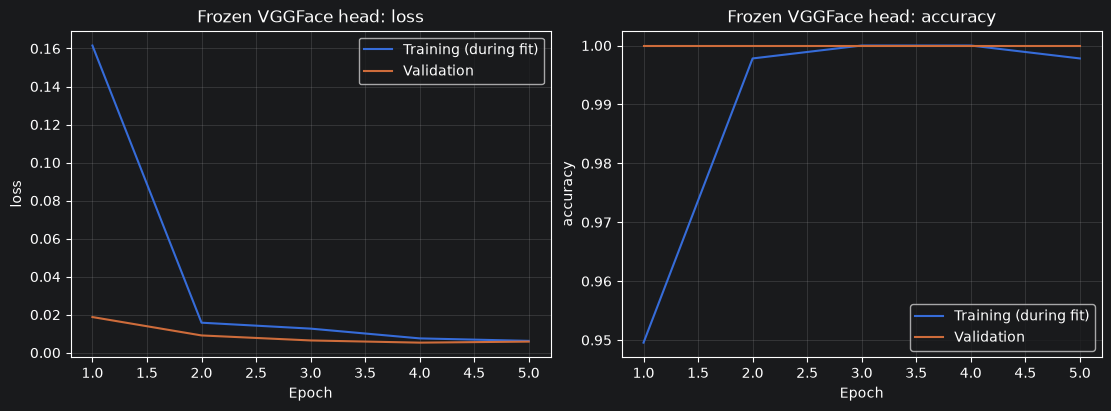

,model,partition,samples,loss,accuracy,balanced_accuracy,macro_auc
0,VGGFace neural head,train,228,0.003689,1.0,1.0,1.0
1,VGGFace neural head,validation,57,0.005288,1.0,1.0,1.0
2,VGGFace neural head,test,72,0.003618,1.0,1.0,1.0


```text
train loss: 0.003689 | accuracy: 1.000000 | balanced accuracy: 1.000000 | AUC: 1.000000
validation loss: 0.005288 | accuracy: 1.000000 | balanced accuracy: 1.000000 | AUC: 1.000000
test loss: 0.003618 | accuracy: 1.000000 | balanced accuracy: 1.000000 | AUC: 1.000000
```

,precision,recall,f1-score,support
Alicia Vikander,1.0,1.0,1.0,23.0
Amy Adams,1.0,1.0,1.0,24.0
Andy Serkis,1.0,1.0,1.0,25.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,72.0
weighted avg,1.0,1.0,1.0,72.0


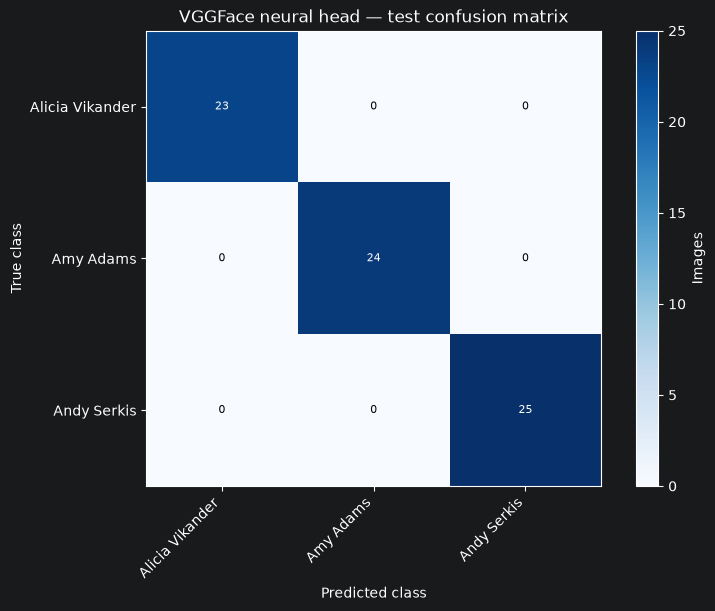

**Answer — transfer learning.** The restored head achieves test accuracy 100.00%, balanced accuracy 100.00%, and macro AUC 1.00000. The majority-class accuracy baseline on this test partition is 34.72%. All frozen weights are byte-for-byte unchanged. These 72 test images are a small educational sample. Some identities/images may overlap the original pretraining population; the supplied dataset cannot establish performance on unseen people or rule out pretraining overlap.

In [19]:
# Repeat the finite flow iterator explicitly to provide two complete passes per epoch.
def repeating_face_batches():
    """Yield two or more traversals without exhausting a Keras PyDataset epoch."""
    while True:
        yield next(face_training_generator)

face_started = perf_counter()
face_history = face_model.fit(
    x=repeating_face_batches(), steps_per_epoch=2 * len(face_training_generator), epochs=5,
    validation_data=(face_processed[face_validation_indices], face_one_hot[face_validation_indices]),
    validation_batch_size=20, shuffle=False,
    callbacks=[utils.TrainingLogger(label="Frozen VGGFace head"), keras.callbacks.ModelCheckpoint(filepath=OUTPUT_DIRECTORY / "face_best.weights.h5", monitor="val_loss", mode="min", save_best_only=True, save_weights_only=True)],
    verbose=0,
)
face_elapsed = perf_counter() - face_started
face_model.load_weights(filepath=OUTPUT_DIRECTORY / "face_best.weights.h5")
assert utils.weight_digest(layers=face_model.layers[:-2]) == frozen_before
face_results = []
for partition, indices in face_indices.items():
    probabilities = face_model.predict(x=face_processed[indices], batch_size=20, verbose=0)
    face_results.append(utils.evaluate_probabilities(model_name="VGGFace neural head", partition=partition, targets=face_targets[indices], probabilities=probabilities, class_names=face_names))
    np.savez_compressed(file=OUTPUT_DIRECTORY / f"face_head_{partition}_predictions.npz", targets=face_targets[indices], probabilities=probabilities)
ALL_RESULTS.extend(face_results)
TRAINING_RECORDS.append({"model": "VGGFace neural head", "epochs": 5, "seconds": face_elapsed, "parameters": face_model.count_params(), "optimizer": "SGD", "learning_rate": 0.01, "batch_size": 20})
utils.plot_history(history=face_history, title="Frozen VGGFace head", output_directory=OUTPUT_DIRECTORY, file_name="face_learning_curves.png")
utils.report_results(results=face_results, class_names=face_names, output_directory=OUTPUT_DIRECTORY, file_name="face_head_confusion_matrix.png")
display(Markdown(data=f"""**Answer — transfer learning.** The restored head achieves test accuracy {face_results[2]['accuracy']:.2%}, balanced accuracy {face_results[2]['balanced_accuracy']:.2%}, and macro AUC {face_results[2]['macro_auc']:.5f}. The majority-class accuracy baseline on this test partition is {np.unique(ar=face_targets[face_test_indices], return_counts=True)[1].max() / len(face_test_indices):.2%}. All frozen weights are byte-for-byte unchanged. These {len(face_test_indices)} test images are a small educational sample. Some identities/images may overlap the original pretraining population; the supplied dataset cannot establish performance on unseen people or rule out pretraining overlap."""))

```Now similar exercise with SVM:```
- ```Create a new model which outputs the data from the last frozen layer. Use this model to create feature for each image.```
- ```Create a SVM classifier using these features. We used sklearn.svm.SVC.```
- ```Did this work better or less good? Evaluate using sklearn.metrics.classification_report or sklearn.metrics.accuracy_score.```
- ```Try the same thing with the one-before-last layer.```

```Think beforhead if the SVM will work better then the NN and discuss with your tutor about the results```

,model,partition,samples,loss,accuracy,balanced_accuracy,macro_auc
0,Linear SVM fc6,train,228,0.019060,1.0,1.0,1.0
1,Linear SVM fc6,validation,57,0.021435,1.0,1.0,1.0
2,Linear SVM fc6,test,72,0.026259,1.0,1.0,1.0


```text
train loss: 0.019060 | accuracy: 1.000000 | balanced accuracy: 1.000000 | AUC: 1.000000
validation loss: 0.021435 | accuracy: 1.000000 | balanced accuracy: 1.000000 | AUC: 1.000000
test loss: 0.026259 | accuracy: 1.000000 | balanced accuracy: 1.000000 | AUC: 1.000000
```

,precision,recall,f1-score,support
Alicia Vikander,1.0,1.0,1.0,23.0
Amy Adams,1.0,1.0,1.0,24.0
Andy Serkis,1.0,1.0,1.0,25.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,72.0
weighted avg,1.0,1.0,1.0,72.0


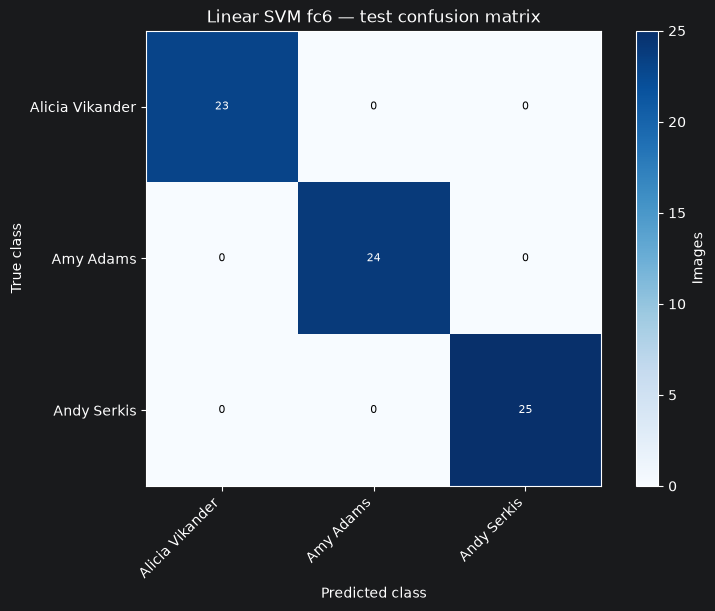

,model,partition,samples,loss,accuracy,balanced_accuracy,macro_auc
0,Linear SVM fc6_relu,train,228,0.016939,1.0,1.0,1.0
1,Linear SVM fc6_relu,validation,57,0.019459,1.0,1.0,1.0
2,Linear SVM fc6_relu,test,72,0.022220,1.0,1.0,1.0


```text
train loss: 0.016939 | accuracy: 1.000000 | balanced accuracy: 1.000000 | AUC: 1.000000
validation loss: 0.019459 | accuracy: 1.000000 | balanced accuracy: 1.000000 | AUC: 1.000000
test loss: 0.022220 | accuracy: 1.000000 | balanced accuracy: 1.000000 | AUC: 1.000000
```

,precision,recall,f1-score,support
Alicia Vikander,1.0,1.0,1.0,23.0
Amy Adams,1.0,1.0,1.0,24.0
Andy Serkis,1.0,1.0,1.0,25.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,72.0
weighted avg,1.0,1.0,1.0,72.0


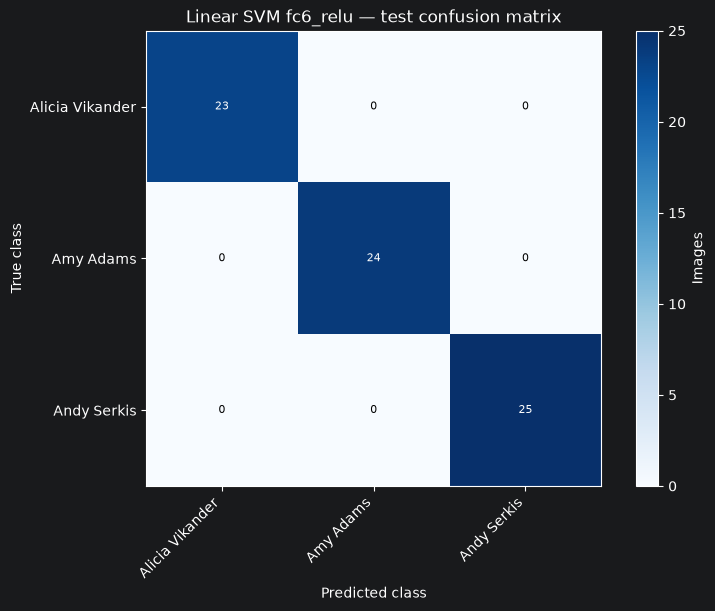

**Answer — SVM comparison.** Validation macro AUC selects **VGGFace neural head** (1.00000); ties follow the fixed table order. Both SVMs use identical partitions, C=1, a linear kernel, and training-only scaling/calibration. They differ only in whether fc6's ReLU has removed negative activations. SVM accuracy uses its native class decisions, while AUC uses calibrated class probabilities; these are distinct outputs. The neural head also differs in classifier, objective, and augmentation, so this comparison does not isolate the implementation library. Test results quantify performance after the selection rule is fixed.

In [20]:
# Solution: compare the retained post-ReLU representation with the layer immediately before it.
feature_model = keras.Model(
    inputs=vgg_model.input,
    outputs=[vgg_model.get_layer(name="fc6").output, vgg_model.get_layer(name="fc6_relu").output],
)
feature_started = perf_counter()
pre_relu_features, post_relu_features = feature_model.predict(x=face_processed, batch_size=20, verbose=0)
np.testing.assert_allclose(actual=post_relu_features, desired=np.maximum(pre_relu_features, 0.0), atol=1e-5)
np.savez_compressed(file=OUTPUT_DIRECTORY / "frozen_face_features.npz", fc6=pre_relu_features, fc6_relu=post_relu_features, targets=face_targets)
svm_models = {}
svm_results = []
for feature_name, features in (("fc6", pre_relu_features), ("fc6_relu", post_relu_features)):
    svm_started = perf_counter()
    classifier = Pipeline(steps=[("standardize", StandardScaler()), ("svm", SVC(C=1.0, kernel="linear", probability=True, random_state=RANDOM_SEED))])
    classifier.fit(X=features[face_training_indices], y=face_targets[face_training_indices])
    np.testing.assert_array_equal(actual=classifier.classes_, desired=np.arange(stop=3))
    np.testing.assert_allclose(actual=classifier.named_steps["standardize"].mean_, desired=features[face_training_indices].mean(axis=0, dtype=np.float64), atol=1e-8)
    current_results = []
    for partition, indices in face_indices.items():
        probabilities = classifier.predict_proba(X=features[indices])
        predictions = classifier.predict(X=features[indices])
        current_results.append(utils.evaluate_probabilities(model_name=f"Linear SVM {feature_name}", partition=partition, targets=face_targets[indices], probabilities=probabilities, predictions=predictions, class_names=face_names))
        np.savez_compressed(file=OUTPUT_DIRECTORY / f"svm_{feature_name}_{partition}_predictions.npz", targets=face_targets[indices], probabilities=probabilities, predictions=predictions)
    svm_models[feature_name] = classifier
    svm_results.extend(current_results)
    TRAINING_RECORDS.append({"model": f"Linear SVM {feature_name}", "epochs": None, "seconds": perf_counter() - svm_started, "parameters": None, "optimizer": "libsvm", "learning_rate": None, "batch_size": None})
    utils.report_results(results=current_results, class_names=face_names, output_directory=OUTPUT_DIRECTORY, file_name=f"svm_{feature_name}_confusion_matrix.png")
    import joblib
    joblib.dump(value=classifier, filename=OUTPUT_DIRECTORY / f"svm_{feature_name}.joblib")
ALL_RESULTS.extend(svm_results)
face_winner = max([result for result in face_results + svm_results if result["partition"] == "validation"], key=lambda result: result["macro_auc"])
display(Markdown(data=f"""**Answer — SVM comparison.** Validation macro AUC selects **{face_winner['model']}** ({face_winner['macro_auc']:.5f}); ties follow the fixed table order. Both SVMs use identical partitions, C=1, a linear kernel, and training-only scaling/calibration. They differ only in whether fc6's ReLU has removed negative activations. SVM accuracy uses its native class decisions, while AUC uses calibrated class probabilities; these are distinct outputs. The neural head also differs in classifier, objective, and augmentation, so this comparison does not isolate the implementation library. Test results quantify performance after the selection rule is fixed."""))

## Final verification and results

The table below uses the same metric definitions throughout. CIFAR-10 and celebrity classification are separate tasks, so their AUC values are not used to rank models across datasets. The final checkpoint and SVM selection use validation data only. The original section-ending reports remain above each relevant answer.

In [22]:
metric_columns = ["model", "partition", "samples", "loss", "accuracy", "balanced_accuracy", "macro_auc"]
comparison_frame = pd.DataFrame(data=[{key: result[key] for key in metric_columns} for result in ALL_RESULTS])
display(comparison_frame)
display(pd.DataFrame(data=TRAINING_RECORDS))
assert len(ALL_RESULTS) == 15
assert len(cnn_history.epoch) == 40
assert len(face_history.epoch) == 5
assert dense_results[0]["accuracy"] > 0.60, "Dense model did not meet the original >60% training accuracy requirement"
assert np.isfinite(comparison_frame[["loss", "accuracy", "balanced_accuracy", "macro_auc"]].to_numpy()).all()
# Reload the actual saved model files and compare predictions with saved results.
for saved_model_name in ("dense", "cnn"):
    restored_model = keras.models.load_model(filepath=OUTPUT_DIRECTORY / f"cifar_{saved_model_name}.keras", compile=False)
    restored_probabilities = restored_model.predict(x=cifar_test_images[:128], batch_size=128, verbose=0)
    with np.load(file=OUTPUT_DIRECTORY / f"{saved_model_name}_test_predictions.npz", allow_pickle=False) as saved_predictions:
        np.testing.assert_allclose(actual=restored_probabilities, desired=saved_predictions["probabilities"][:128], rtol=1e-5, atol=1e-6)
    LOGGER.info("Saved %s model prediction round-trip passed", saved_model_name)
    del restored_model
display(Markdown(data="**Reading the results:** CIFAR-10 has equal class counts in each partition, so accuracy and balanced accuracy coincide. Occlusion always marks 80 centers, even for a nearly constant probability map; red marks alone do not establish a large effect."))
payload = {
    "seed": RANDOM_SEED, "results": ALL_RESULTS, "training": TRAINING_RECORDS,
    "selected_cifar_model": cifar_winner["model"], "selected_face_model": face_winner["model"],
    "face_class_names": face_names, "cifar_class_names": cifar_names,
    "assets": asset_manifest, "frozen_weights_unchanged": True,
    "elapsed_seconds": perf_counter() - NOTEBOOK_STARTED,
}
(OUTPUT_DIRECTORY / "metrics.json").write_text(data=json.dumps(obj=payload, indent=2), encoding="utf-8")
history_payload = {"dense": dense_history.history, "cnn": cnn_history.history, "face": face_history.history}
(OUTPUT_DIRECTORY / "learning_histories.json").write_text(data=json.dumps(obj=history_payload, indent=2), encoding="utf-8")
LOGGER.info("All notebook correctness and assignment checks passed.")
LOGGER.info("Metrics: %s", OUTPUT_DIRECTORY / "metrics.json")
LOGGER.info("Timestamped output directory: %s", OUTPUT_DIRECTORY)
display(Markdown(data=f"**Execution checks passed.** Metrics, figures, predictions, and model artifacts: {OUTPUT_DIRECTORY}. The verified Excel workbook is exported from these same metric records after execution."))

,model,partition,samples,loss,accuracy,balanced_accuracy,macro_auc
0,CIFAR dense,train,45000,0.824398,0.705889,0.705889,0.959496
1,CIFAR dense,validation,5000,1.587069,0.513000,0.513000,0.879567
2,CIFAR dense,test,10000,1.549163,0.517700,0.517700,0.882700
3,CIFAR CNN,train,45000,0.287662,0.901133,0.901133,0.994556
4,CIFAR CNN,validation,5000,0.635283,0.788400,0.788400,0.977033
5,CIFAR CNN,test,10000,0.643458,0.786200,0.786200,0.976791
6,VGGFace neural head,train,228,0.003689,1.000000,1.000000,1.000000
7,VGGFace neural head,validation,57,0.005288,1.000000,1.000000,1.000000
8,VGGFace neural head,test,72,0.003618,1.000000,1.000000,1.000000
9,Linear SVM fc6,train,228,0.019060,1.000000,1.000000,1.000000


,model,epochs,seconds,parameters,optimizer,learning_rate,batch_size
0,CIFAR dense,40.0,129.392962,1662360.0,Adam,0.001,128.0
1,CIFAR CNN,40.0,553.674393,387778.0,Adam,0.001,128.0
2,VGGFace neural head,5.0,176.398401,117889235.0,SGD,0.010,20.0
3,Linear SVM fc6,NaN,0.243586,NaN,libsvm,NaN,NaN
4,Linear SVM fc6_relu,NaN,0.331847,NaN,libsvm,NaN,NaN


2026-09-07 17:34:11,274 | INFO | Saved dense model prediction round-trip passed
2026-09-07 17:34:11,587 | INFO | Saved cnn model prediction round-trip passed


**Reading the results:** CIFAR-10 has equal class counts in each partition, so accuracy and balanced accuracy coincide. Occlusion always marks 80 centers, even for a nearly constant probability map; red marks alone do not establish a large effect.

2026-09-07 17:34:11,594 | INFO | All notebook correctness and assignment checks passed.
2026-09-07 17:34:11,596 | INFO | Metrics: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part2\outputs\cnn_20260907_171753\metrics.json
2026-09-07 17:34:11,602 | INFO | Timestamped output directory: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part2\outputs\cnn_20260907_171753


**Execution checks passed.** Metrics, figures, predictions, and model artifacts: C:\Users\asherk\PycharmProjects\DS_Training\E - nn_intro\part2\outputs\cnn_20260907_171753. The verified Excel workbook is exported from these same metric records after execution.